In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
df = pd.read_csv('Algerian_forest_fires_cleaned(2).csv')

In [7]:
X = df.drop('FWI',axis=1)
y=df['FWI']

In [8]:
from sklearn.model_selection import train_test_split


In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [10]:
def correlation(dataset, threashold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threashold:
                col_name = corr_matrix.columns[i]
                col_corr.add(col_name)
    return col_corr

In [11]:
corr_features = correlation(X_train,0.80)

In [18]:
corr_features

{'BUI', 'DC'}

In [12]:
X_train.drop(corr_features, axis=1, inplace=True)
X_test.drop(corr_features, axis=1, inplace= True)


In [4]:
from sklearn.preprocessing import StandardScaler

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Mean absolute error 0.5192048325844728
R2 Score 0.9801058063273602


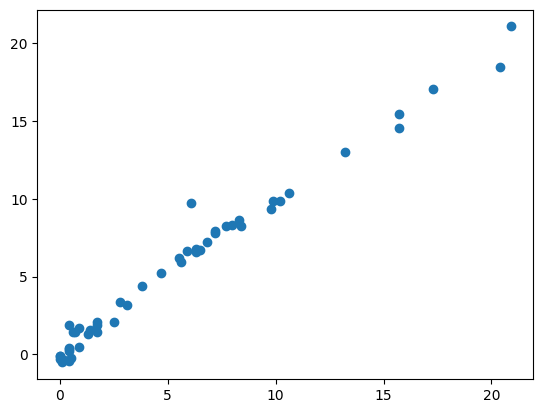

In [14]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridge=Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred=ridge.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

In [15]:
scaler

StandardScaler()

In [16]:
ridge

Ridge()

In [2]:
import pickle

In [17]:
pickle.dump(scaler,open('scaler.pkl','wb'))
pickle.dump(ridge,open('ridge.pkl','wb'))